# Google Colab Setting

In [37]:
!pip install -q "numpy<2.0" "pandas<2.2" refinitiv-data fredapi optuna xgboost tqdm scikit-learn

^C
ERROR: Operation cancelled by user


# Package imports

In [28]:
import os

# Prevent duplicate OpenMP runtime errors when running on macOS or Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Restrict CPU thread count to avoid over-subscription on shared machines
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"


In [29]:
# Data manipulation
import pandas as pd
import numpy as np

# Market data APIs
import refinitiv.data as rd
from fredapi import Fred

# Standard library
import datetime as dt
import json
import os

# Feature selection
from xgboost import XGBRegressor
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Hyperparameter optimisation
import optuna

# Visualisation & progress
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# Data Acquisition

In [30]:
# ── Date range ────────────────────────────────────────────────────────────────
START = "2000-01-01"
END = dt.datetime.today().strftime("%Y-%m-%d")

# ── Ticker universes ──────────────────────────────────────────────────────────
# All Refinitiv symbols to fetch (includes DXY as a macro proxy)
REFINITIV_TICKERS = ["SPY", "TLT.O", "GLD", "XLE", ".DXY"]
# Assets we generate return forecasts for
TARGET_TICKERS = ["SPY", "TLT.O", "GLD", "XLE"]

# FRED series → human-readable column names
FRED_TICKERS = {
    "T10Y2Y":     "Term_Spread",        # 10Y-2Y Treasury yield spread
    "BAA10Y":     "Credit_Spread",      # Baa corporate - 10Y Treasury spread
    "T10YIE":     "Breakeven_Inflation",# 10Y breakeven inflation rate
    "VIXCLS":     "VIX",                # CBOE Volatility Index
    "NASDAQXAU":  "Gold_Spot",          # Gold spot price (USD/oz)
    "DCOILWTICO": "WTI_Crude",          # WTI crude oil spot price
}

# ── File paths ────────────────────────────────────────────────────────────────
OUT_PATH    = "../data/merged_daily.csv"   # raw merged dataset
DATASET_DIR = "../data"                    # per-target feature datasets

# SAVE_DIR = "/content/drive/MyDrive/vsn_lstm_results"  # Google Colab
SAVE_DIR = "../model"   # model checkpoints and results

# ── Macro feature transformation groups ──────────────────────────────────────
# Level + first-difference representation for spread series
MACRO_LEVEL_DIFF = ["Term_Spread", "Credit_Spread", "Breakeven_Inflation", "VIX"]
# Log-return representation for price-like macro series
MACRO_LOG_RETURN = ["Gold_Spot", "WTI_Crude"]


In [31]:
def key_loader(filepath):
    """Load the Refinitiv app-key from a JSON config file.

    Parameters
    ----------
    filepath : str
        Path to the Refinitiv ``refinitiv-data.config.json`` file.

    Returns
    -------
    str
        App-key string for authenticating with the Refinitiv Data API.

    Raises
    ------
    FileNotFoundError
        If the config file does not exist at ``filepath``.
    KeyError
        If the expected key path is missing inside the JSON structure.
    """
    try:
        with open(filepath) as f:
            app_key = json.load(f)['sessions']['platform']['rdp']['app-key']
        print("Key loaded successfully")
        return app_key
    except FileNotFoundError:
        print(f"Error: '{filepath}' not found.")
        raise
    except KeyError as e:
        print(f"Error: missing key {e}.")
        raise


In [32]:
def check_state(state, message, session):
    """Callback for Refinitiv session state-change events.

    Registered via ``session.on_state()``. Prints state transitions and
    associated messages to stdout for debugging connection issues.

    Parameters
    ----------
    state : str
        New session state (e.g. "Opened", "Closed", "Failed").
    message : str
        Descriptive message accompanying the state change.
    session : rd.session.Session
        The session object that triggered the callback.
    """
    print(f"State: {state}")
    print(f"Message: {message}")
    print("\n")


In [33]:
def fetch_refinitiv_data(tickers, start_date, end_date, app_key):
    """
    Fetch target assets' OHLCV and adjusted prices from Refinitiv Data API.
    
    :param tickers: list of ticker symbols
    :param start_date: start date (YYYY-MM-DD)
    :param end_date: end date (YYYY-MM-DD)
    :param app_key: Refinitiv app key
    :return: DataFrame with OHLCV data
    """
    session = None
    try:
        session = rd.session.desktop.Definition(app_key=app_key).get_session()
        rd.session.set_default(session)
        session.on_state(check_state)
        session.open()

        fields = [
            "TR.PriceOpen",
            "TR.PriceHigh",
            "TR.PriceLow",
            "TR.PriceClose",
            "TR.Volume"
        ]

        frames = []
        for ticker in tickers:
            print(f"[REFINITIV] Fetching {ticker} ...")
            try:
                tdf = rd.get_history(
                    universe=[ticker],
                    fields=fields,
                    interval="1D",
                    start=start_date,
                    end=end_date
                )

                if tdf is None or tdf.empty:
                    print(f"[REFINITIV] {ticker}: EMPTY")
                    continue

                tdf.index = pd.to_datetime(tdf.index)
                try:
                    tdf.index = tdf.index.tz_localize(None)
                except (TypeError, AttributeError):
                    pass

                # Remove duplicate dates from Refinitiv (can occur at DST boundary)
                tdf = tdf[~tdf.index.duplicated(keep='last')]

                if isinstance(tdf.columns, pd.MultiIndex):
                    tdf.columns = [f"{tic}_{fld}" for tic, fld in tdf.columns]
                else:
                    tdf.columns = [f"{ticker}_{col}" for col in tdf.columns]

                print(f"[REFINITIV] {ticker}: OK | rows={len(tdf)} | {tdf.index.min().date()} -> {tdf.index.max().date()}")
                frames.append(tdf)
            except Exception as e:
                print(f"[REFINITIV] {ticker}: FAIL | {e}")

        if not frames:
            raise ValueError("No Refinitiv data was fetched successfully.")

        df = pd.concat(frames, axis=1).sort_index()
        return df
    finally:
        if session is not None:
            session.close()

In [34]:
def fetch_fred_data(tickers_dict, start_date, end_date):
    """
    Fetch macro and alternative indicators using the fredapi library.
    Key resolution: $FRED_API_KEY -> secrets.json -> error.
    """
    api_key = os.environ.get("FRED_API_KEY")
    if not api_key:
        with open("secrets.json") as f:
            api_key = json.load(f)["fred_api_key"]

    fred = Fred(api_key=api_key)
    combined_fred_data = pd.DataFrame()

    for ticker, name in tickers_dict.items():
        print(f"[FRED] Fetching {ticker} ({name}) ...")
        try:
            series = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
            if series is None or len(series) == 0:
                print(f"[FRED] {ticker}: EMPTY")
                continue

            combined_fred_data[name] = series
            sidx = pd.to_datetime(series.index)
            print(f"[FRED] {ticker}: OK | rows={len(series)} | {sidx.min().date()} -> {sidx.max().date()}")
        except Exception as e:
            print(f"[FRED] {ticker}: FAIL | {e}")

    combined_fred_data.index = pd.to_datetime(combined_fred_data.index)
    return combined_fred_data


In [10]:
def get_raw_dataset(start_date=START, end_date=END, filepath='refinitiv-data.config.json'):
    """Fetch, merge, and clean market + macro data into a single daily DataFrame.

    Workflow
    --------
    1. Fetch OHLCV data for ``REFINITIV_TICKERS`` via Refinitiv Data API.
    2. Fetch macro/alt indicators for ``FRED_TICKERS`` via FRED API.
    3. Left-join on the market calendar; forward-fill FRED gaps (weekends /
       holidays); drop rows where any target close price is missing.

    Parameters
    ----------
    start_date : str
        Start of the data window in "YYYY-MM-DD" format.
    end_date : str
        End of the data window in "YYYY-MM-DD" format.
    filepath : str
        Path to the Refinitiv config file consumed by ``key_loader``.

    Returns
    -------
    pd.DataFrame
        Cleaned, merged daily DataFrame indexed by trading date.
    """
    app_key = key_loader(filepath)
    df_market = fetch_refinitiv_data(REFINITIV_TICKERS, start_date, end_date, app_key)
    df_macro  = fetch_fred_data(FRED_TICKERS, start_date, end_date)

    # Left-join on equity calendar; FRED series have weekend/holiday gaps
    df_merged = df_market.join(df_macro, how="left")
    df_merged = df_merged.apply(pd.to_numeric, errors='coerce')
    # Forward-fill macro values across non-trading days
    df_merged = df_merged.ffill()

    # Drop dates where any target's close price is unavailable
    close_cols = [f"{t}_Price Close" for t in TARGET_TICKERS
                  if f"{t}_Price Close" in df_merged.columns]
    df_merged = df_merged.dropna(subset=close_cols, how='any')
    # DXY has no meaningful volume column — remove it
    df_merged = df_merged.drop([".DXY_Volume"], axis=1, errors="ignore")

    return df_merged


In [11]:
filepath = 'refinitiv-data.config.json'
df = get_raw_dataset(filepath=filepath)
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Key loaded successfully
State: OpenState.Pending
Message: Session opening in progress


State: OpenState.Opened
Message: Session is opened


[REFINITIV] Fetching SPY ...
[REFINITIV] SPY: OK | rows=6657 | 2000-01-03 -> 2026-04-21
[REFINITIV] Fetching TLT.O ...
[REFINITIV] TLT.O: OK | rows=6653 | 2000-01-03 -> 2026-04-21
[REFINITIV] Fetching GLD ...
[REFINITIV] GLD: OK | rows=6657 | 2000-01-03 -> 2026-04-21
[REFINITIV] Fetching XLE ...
[REFINITIV] XLE: OK | rows=6657 | 2000-01-03 -> 2026-04-21
[REFINITIV] Fetching .DXY ...
[REFINITIV] .DXY: OK | rows=6862 | 2000-01-03 -> 2026-04-21
State: OpenState.Closed
Message: Session is closed


[FRED] Fetching T10Y2Y (Term_Spread) ...


/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_60224/762530133.py:64:Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.


[FRED] T10Y2Y: OK | rows=6861 | 2000-01-03 -> 2026-04-20
[FRED] Fetching BAA10Y (Credit_Spread) ...
[FRED] BAA10Y: OK | rows=6860 | 2000-01-03 -> 2026-04-17
[FRED] Fetching T10YIE (Breakeven_Inflation) ...
[FRED] T10YIE: OK | rows=6078 | 2003-01-02 -> 2026-04-20
[FRED] Fetching VIXCLS (VIX) ...
[FRED] VIXCLS: OK | rows=6861 | 2000-01-03 -> 2026-04-20
[FRED] Fetching NASDAQXAU (Gold_Spot) ...
[FRED] NASDAQXAU: OK | rows=5643 | 2004-09-02 -> 2026-04-20
[FRED] Fetching DCOILWTICO (WTI_Crude) ...
[FRED] DCOILWTICO: OK | rows=6856 | 2000-01-03 -> 2026-04-13
Data shape: (5589, 30)
Date range: 2004-11-18 00:00:00 to 2026-04-21 00:00:00


In [12]:
df

,SPY_Price Open,SPY_Price High,SPY_Price Low,SPY_Price Close,SPY_Volume,TLT.O_Price Open,TLT.O_Price High,TLT.O_Price Low,TLT.O_Price Close,TLT.O_Volume,...,.DXY_Price Open,.DXY_Price High,.DXY_Price Low,.DXY_Price Close,Term_Spread,Credit_Spread,Breakeven_Inflation,VIX,Gold_Spot,WTI_Crude
Date,,,,,,,,,,,,,,,,,,,,,
2004-11-18,118.49,118.80,118.23,118.74,31910700.0,88.550,89.060,88.410,88.97,891500.0,...,83.320,83.900,83.100,83.690,1.26,2.01,2.48,12.98,108.33,46.30
2004-11-19,118.70,118.72,117.14,117.42,54280400.0,88.900,89.030,88.090,88.26,1244500.0,...,83.870,83.910,83.010,83.310,1.25,1.99,2.53,13.50,109.69,48.90
2004-11-22,117.17,118.12,117.03,117.98,37574400.0,88.350,88.870,88.300,88.72,511500.0,...,83.270,83.390,83.080,83.190,1.23,1.96,2.56,12.97,109.69,48.48
2004-11-23,117.93,118.26,117.37,118.16,41973400.0,88.500,89.200,88.480,88.83,747600.0,...,83.170,83.540,82.810,82.970,1.21,1.96,2.54,12.67,107.71,48.74
2004-11-24,118.27,118.59,118.05,118.44,29735000.0,88.910,88.910,88.730,88.83,309700.0,...,82.900,82.960,82.360,82.410,1.19,1.95,2.56,12.72,107.21,49.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-15,695.26,700.28,694.20,699.94,58240384.0,87.020,87.070,86.725,86.83,15119636.0,...,98.067,98.285,98.005,98.055,0.53,1.69,2.39,18.17,399.99,100.72
2026-04-16,701.06,702.78,698.53,701.66,49972363.0,86.915,86.970,86.200,86.28,20001034.0,...,98.012,98.292,97.832,98.215,0.54,1.71,2.39,17.94,398.38,100.72
2026-04-17,706.14,712.39,705.76,710.14,70661926.0,87.050,87.210,86.890,87.07,29604128.0,...,98.189,98.291,97.632,98.098,0.55,1.72,2.36,17.48,410.91,100.72


In [13]:
df.to_csv(OUT_PATH)

# Data Preprocessing

In [35]:
df = pd.read_csv(OUT_PATH, index_col=0, parse_dates=True)

In [36]:
def transform_macro(df, level_diff_cols, log_return_cols):
    """Transform raw macro series into model-ready stationary features.

    Two transformations are applied depending on the nature of each series:

    * **Level + first-difference** (``level_diff_cols``): suitable for
      spread-type series (e.g., VIX, yield spreads) where both the absolute
      level and its daily change carry distinct information.
    * **Log-return** (``log_return_cols``): suitable for price-like series
      (e.g., crude oil, gold) to achieve stationarity.

    DXY (US Dollar Index) is always log-differenced when present.

    Parameters
    ----------
    df : pd.DataFrame
        Raw merged dataset containing the macro columns.
    level_diff_cols : list of str
        Column names to represent as (level, first-difference) pairs.
    log_return_cols : list of str
        Column names to represent as log-returns.

    Returns
    -------
    pd.DataFrame
        Transformed macro features aligned to the original date index.
    """
    out = pd.DataFrame(index=df.index)

    for col in level_diff_cols:
        if col in df.columns:
            out[f"{col}_level"] = df[col]
            out[f"{col}_diff"]  = df[col].diff()

    for col in log_return_cols:
        if col in df.columns:
            out[f"{col}_logret"] = np.log(
                df[col].clip(lower=1e-10) / df[col].shift(1).clip(lower=1e-10)
            )

    # DXY: log-return (price-like behaviour)
    if ".DXY_Price Close" in df.columns:
        dxy = pd.to_numeric(df[".DXY_Price Close"], errors="coerce")
        out["DXY_logret"] = np.log(
            dxy.clip(lower=1e-10) / dxy.shift(1).clip(lower=1e-10)
        )

    return out


# Feature Engineering

In [37]:
def compute_technical_features(close):
    """Compute price-based technical indicators from a close-price series.

    Features computed
    -----------------
    ret_1d  : 1-day log return
    ret_5d  : 5-day (weekly) log return
    ret_20d : 20-day (monthly) log return
    macd    : MACD line (EMA-12 minus EMA-26)
    rsi_14  : 14-period Wilder RSI
    vol_20d : 20-day realised volatility (annualised)

    Parameters
    ----------
    close : pd.Series
        Daily close-price series for a single asset.

    Returns
    -------
    pd.DataFrame
        DataFrame of technical features aligned to ``close.index``.
    """
    out = pd.DataFrame(index=close.index)

    # Multi-horizon log returns
    ret_1d = np.log(close / close.shift(1))
    out["ret_1d"]  = ret_1d
    out["ret_5d"]  = np.log(close / close.shift(5))
    out["ret_20d"] = np.log(close / close.shift(20))

    # MACD: difference of exponential moving averages
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    out["macd"] = ema_12 - ema_26

    # RSI: Wilder smoothing (alpha = 1/14)
    delta = close.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    out["rsi_14"] = 100 - 100 / (1 + gain / loss)

    # Annualised realised volatility over a 20-day rolling window
    out["vol_20d"] = ret_1d.rolling(20).std() * np.sqrt(252)

    return out


def build_target_dataset(df, target, macro_features):
    """Assemble the full feature matrix and t+1 log-return target for one asset.

    Concatenates per-asset technical features, shared macro features, and the
    forward 1-day log return, then drops any rows containing NaN values.

    Parameters
    ----------
    df : pd.DataFrame
        Raw merged dataset (output of ``get_raw_dataset``).
    target : str
        Target ticker symbol (e.g., ``"SPY"``).
    macro_features : pd.DataFrame
        Transformed macro features (output of ``transform_macro``).

    Returns
    -------
    pd.DataFrame
        Feature + target DataFrame ready for sequence modelling.
    """
    close = df[f"{target}_Price Close"]
    # Prefix technical features with the ticker name to avoid column conflicts
    tech  = compute_technical_features(close).add_prefix(f"{target}_")
    # t+1 log return: shifted by -1 so each row's target is the *next* day's return
    y = np.log(close.shift(-1) / close).rename("target")
    return pd.concat([tech, macro_features, y], axis=1).dropna()


In [38]:
macro_features = transform_macro(df, MACRO_LEVEL_DIFF, MACRO_LOG_RETURN)
datasets = {t: build_target_dataset(df, t, macro_features) for t in TARGET_TICKERS}

for t, data in datasets.items():
    print(f"{t}: shape={data.shape}, range={data.index.min().date()} -> {data.index.max().date()}")

SPY: shape=(5568, 18), range=2004-12-16 -> 2026-04-20
TLT.O: shape=(5568, 18), range=2004-12-16 -> 2026-04-20
GLD: shape=(5568, 18), range=2004-12-16 -> 2026-04-20
XLE: shape=(5568, 18), range=2004-12-16 -> 2026-04-20


In [39]:
os.makedirs(DATASET_DIR, exist_ok=True)

for target, data in datasets.items():
    safe_name = target.replace(".", "_")
    data.to_csv(f"{DATASET_DIR}/{safe_name}_dataset.csv")
    print(f"Saved: {safe_name}_dataset.csv | shape={data.shape}")


Saved: SPY_dataset.csv | shape=(5568, 18)
Saved: TLT_O_dataset.csv | shape=(5568, 18)
Saved: GLD_dataset.csv | shape=(5568, 18)
Saved: XLE_dataset.csv | shape=(5568, 18)


# Feature Selection

In [40]:
# Load datasets from CSV
datasets = {}
for target in TARGET_TICKERS:
    safe_name = target.replace(".", "_")
    path = f"{DATASET_DIR}/{safe_name}_dataset.csv"
    datasets[target] = pd.read_csv(path, index_col=0, parse_dates=True)
    print(f"Loaded: {safe_name}_dataset.csv | shape={datasets[target].shape}")

Loaded: SPY_dataset.csv | shape=(5568, 18)
Loaded: TLT_O_dataset.csv | shape=(5568, 18)
Loaded: GLD_dataset.csv | shape=(5568, 18)
Loaded: XLE_dataset.csv | shape=(5568, 18)


## Correlation Test

In [41]:
# ── Feature selection hyper-parameters ───────────────────────────────────────
SPEARMAN_THRESHOLD = 0.90   # Features with |Spearman ρ| > threshold are clustered
TOP_K = 12                  # Final number of features selected by XGBoost stage


def stage1_redundancy_filter(X, y, threshold=SPEARMAN_THRESHOLD):
    """Remove redundant features via Spearman correlation + Ward hierarchical clustering.

    Algorithm
    ---------
    1. Compute the pairwise absolute Spearman correlation matrix of ``X``.
    2. Convert to a distance matrix (distance = 1 - |ρ|).
    3. Apply Ward linkage and cut at ``1 - threshold`` to form clusters.
    4. Within each cluster, retain only the feature most correlated with ``y``
       (highest absolute Spearman IC with the target).

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix (rows = samples, columns = features).
    y : pd.Series
        Target series aligned to ``X``.
    threshold : float
        Spearman correlation threshold above which two features are considered
        redundant. Default is ``SPEARMAN_THRESHOLD`` (0.90).

    Returns
    -------
    list of str
        Names of the selected (representative) features, one per cluster.
    """
    corr     = X.corr(method='spearman').abs()
    dist     = (1 - corr).clip(lower=0)
    dist_arr = dist.values.copy()
    np.fill_diagonal(dist_arr, 0)
    condensed = squareform(dist_arr, checks=False)
    Z      = linkage(condensed, method='ward')
    labels = fcluster(Z, t=1 - threshold, criterion='distance')

    # Compute Spearman IC of each feature with the target
    ic = X.corrwith(y, method='spearman').abs()
    selected = []

    # Keep the highest-IC feature from each cluster
    for cid in np.unique(labels):
        cols = X.columns[labels == cid].tolist()
        selected.append(ic[cols].idxmax())

    return selected


## XGBoost Feature Importance

In [42]:
def stage2_relevance_filter(X, y, top_k=TOP_K):
    """Rank features by XGBoost importance and return the top-K most relevant.

    Fits a shallow gradient-boosted tree ensemble on the (already de-duplicated)
    feature set and uses the built-in ``feature_importances_`` to rank features
    by predictive relevance to the target.

    Parameters
    ----------
    X : pd.DataFrame
        De-duplicated feature matrix (output of ``stage1_redundancy_filter``).
    y : pd.Series
        Target series aligned to ``X``.
    top_k : int
        Number of features to retain. Default is ``TOP_K``.

    Returns
    -------
    pd.Series
        Top-K feature importances, index = feature names, values = importance scores.
    """
    xgb_device = "cuda" if torch.cuda.is_available() else "cpu"
    model = XGBRegressor(
        max_depth=3, n_estimators=100, random_state=42, verbosity=0,
        device=xgb_device, tree_method="hist",
    )
    model.fit(X, y)
    importances = pd.Series(model.feature_importances_, index=X.columns)
    return importances.nlargest(top_k)   # Series (feature → importance)


In [43]:
def select_features(X, y, top_k=TOP_K):
    """Two-stage feature selection pipeline: redundancy filter → relevance filter.

    Stage 1 — Redundancy filter (``stage1_redundancy_filter``):
        Groups highly correlated features into clusters via Ward hierarchical
        clustering on Spearman distance and retains the most informative
        representative from each cluster.

    Stage 2 — Relevance filter (``stage2_relevance_filter``):
        Ranks the remaining features by XGBoost importance and keeps the
        top ``top_k`` most predictive features.

    Parameters
    ----------
    X : pd.DataFrame
        Full feature matrix for a single asset.
    y : pd.Series
        Corresponding target (t+1 log return) series.
    top_k : int
        Final number of features to select.

    Returns
    -------
    feature_list : list of str
        Ordered list of selected feature names.
    importances : pd.Series
        XGBoost importance scores for the selected features.
    """
    stage1 = stage1_redundancy_filter(X, y)
    stage2 = stage2_relevance_filter(X[stage1], y, top_k=top_k)
    return stage2.index.tolist(), stage2   # (feature_list, importance_series)


# VSN Embedding

In [44]:
# ── Walk-forward validation parameters ───────────────────────────────────────
LOOKBACK            = 20    # Input sequence length (trading days ≈ 1 month)
INITIAL_TRAIN_YEARS = 5     # Minimum training window for the first fold
TEST_SIZE           = 60    # Test window per fold (trading days ≈ 1 quarter)
EMBARGO             = LOOKBACK  # Gap between train end and test start to prevent
                                # label leakage via overlapping return windows


def make_sequence_dataset(data, feature_cols, lookback=LOOKBACK):
    """Convert a tabular DataFrame into overlapping fixed-length sequences for LSTM input.

    For each timestep ``t`` in ``[lookback, len(data))``, constructs an input
    tensor ``X[t]`` of shape ``(lookback, num_features)`` from rows
    ``[t - lookback : t]`` and a scalar target ``y[t]``.

    Parameters
    ----------
    data : pd.DataFrame
        Scaled feature DataFrame that includes a "target" column.
    feature_cols : list of str
        Column names to use as model inputs (must not include "target").
    lookback : int
        Number of past timesteps in each input sequence.

    Returns
    -------
    X : torch.Tensor, shape (N, lookback, num_features)
    y : torch.Tensor, shape (N,)
        Returns empty tensors if ``data`` is too short to form any sequence.
    """
    X = data[feature_cols].values.astype(np.float32)
    y = data["target"].values.astype(np.float32)
    xs, ys = [], []
    for i in range(lookback, len(data)):
        xs.append(X[i - lookback:i])
        ys.append(y[i])
    if not xs:
        return torch.empty(0, lookback, len(feature_cols)), torch.empty(0)
    return torch.tensor(np.array(xs)), torch.tensor(np.array(ys))


In [45]:
class GatedResidualNetwork(nn.Module):
    """Gated Residual Network (GRN) as used in the Temporal Fusion Transformer.

    Applies a two-layer MLP with ELU activation followed by a Gated Linear Unit
    (GLU) gating mechanism and a residual (skip) connection with Layer Normalization.

    Architecture
    ------------
    z = ELU(fc1(x))
    z = dropout(fc2(z))
    a, b = split(gate(z))        # GLU: element-wise gating
    z = a * sigmoid(b)
    out = LayerNorm(z + skip(x)) # skip projects x if dim changes

    Parameters
    ----------
    input_dim : int
        Dimensionality of the input features.
    hidden_dim : int
        Dimensionality of the hidden / output representation.
    dropout : float
        Dropout probability applied after the second linear layer.
    """
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.fc1     = nn.Linear(input_dim, hidden_dim)
        self.fc2     = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.gate    = nn.Linear(hidden_dim, 2 * hidden_dim)  # GLU: outputs a and b
        # Project input to hidden_dim for residual connection if dims differ
        self.skip    = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()
        self.norm    = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        z = torch.nn.functional.elu(self.fc1(x))
        z = self.fc2(z)
        z = self.dropout(z)
        # Gated Linear Unit: split into activation (a) and gate (b)
        a, b = self.gate(z).chunk(2, dim=-1)
        z = a * torch.sigmoid(b)
        return self.norm(z + self.skip(x))


In [46]:
class VariableSelectionNetwork(nn.Module):
    """Variable Selection Network (VSN) for dynamic, input-dependent feature weighting.

    Each input feature is first projected independently through its own GRN
    (``feature_grns``). A separate GRN (``selection_grn``) receives the full
    raw input and produces a softmax-normalised weight vector that acts as an
    attention mask over the per-feature embeddings.

    This allows the model to adaptively suppress uninformative features on a
    per-sample and per-timestep basis, which is especially useful for financial
    time series where feature relevance shifts across market regimes.

    Parameters
    ----------
    num_features : int
        Number of input features (= width of the feature dimension).
    hidden_dim : int
        Output dimensionality for each feature GRN and the context vector.
    dropout : float
        Dropout probability passed to all GRN sub-modules.

    Inputs
    ------
    x : torch.Tensor, shape (batch, time, num_features)

    Outputs
    -------
    context : torch.Tensor, shape (batch, time, hidden_dim)
        Weighted sum of per-feature embeddings.
    weights : torch.Tensor, shape (batch, time, num_features)
        Softmax selection weights (interpretable as feature importance per step).
    """
    def __init__(self, num_features, hidden_dim, dropout=0.1):
        super().__init__()
        # One GRN per feature: projects scalar feature value to hidden_dim
        self.feature_grns  = nn.ModuleList(
            [GatedResidualNetwork(1, hidden_dim, dropout) for _ in range(num_features)]
        )
        # Selection GRN: maps full input vector to per-feature selection weights
        self.selection_grn = GatedResidualNetwork(num_features, num_features, dropout)

    def forward(self, x):
        # x: [batch, time, features]
        # Stack per-feature embeddings: [batch, time, features, hidden_dim]
        feat = torch.stack(
            [grn(x[:, :, i:i + 1]) for i, grn in enumerate(self.feature_grns)], dim=2
        )
        # Compute softmax selection weights from the full input context
        weights = torch.softmax(self.selection_grn(x), dim=-1).unsqueeze(-1)
        # Weighted sum across the feature dimension → context vector
        context = (feat * weights).sum(dim=2)
        return context, weights.squeeze(-1)


In [47]:
def expanding_window_folds(n, initial_train, test_size, embargo, purge=0):
    """Generate (train_idx, test_idx) pairs for expanding-window walk-forward validation.

    In each fold the training set grows by ``test_size`` rows (anchored at the
    beginning of the dataset), separated from the test window by an embargo gap
    to prevent label leakage from overlapping return horizons.

    Parameters
    ----------
    n : int
        Total number of rows in the dataset.
    initial_train : int
        Size of the training set in the first fold (≈ INITIAL_TRAIN_YEARS × 252).
    test_size : int
        Number of rows in each test window.
    embargo : int
        Number of rows between the last training row and the first test row.
        Prevents look-ahead bias when the prediction target has a multi-day
        horizon that would overlap with the next training row.
    purge : int, optional
        Drop the last ``purge`` rows from each training set to remove samples
        whose label horizon explicitly overlaps the embargo/test region.
        For daily t+1 targets with ``embargo >= 1`` this is already satisfied,
        so the default is 0.

    Returns
    -------
    list of (np.ndarray, np.ndarray)
        Each element is a ``(train_idx, test_idx)`` pair of integer arrays.
    """
    folds     = []
    train_end = initial_train
    while train_end + embargo + test_size <= n:
        train_idx  = np.arange(0, max(train_end - purge, 1))
        test_start = train_end + embargo
        test_end   = test_start + test_size
        test_idx   = np.arange(test_start, test_end)
        folds.append((train_idx, test_idx))
        train_end += test_size
    return folds


# LSTM Model

In [48]:
# ── Device selection ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
    torch.backends.cudnn.benchmark = True           # Auto-tune convolution kernels
    torch.set_float32_matmul_precision("high")      # Allow TF32 on Ampere+ GPUs
elif torch.backends.mps.is_available():
    DEVICE = "mps"    # Apple Silicon GPU
else:
    DEVICE = "cpu"
    torch.set_num_threads(4)

print(f"Using device: {DEVICE}")

# ── Fallback hyperparameters (used when Optuna tuning is skipped) ─────────────
DEFAULT_PARAMS = {
    "vsn_hidden_dim":  32,    # VSN embedding dimension
    "lstm_hidden_dim": 32,    # LSTM hidden state size
    "lstm_num_layers": 1,     # Number of stacked LSTM layers
    "lstm_dropout":    0.0,   # LSTM inter-layer dropout (active only if num_layers > 1)
    "vsn_dropout":     0.1,   # VSN GRN dropout
    "lr":              1e-3,  # Initial learning rate
    "batch_size":      64,    # Mini-batch size
}

# ── Training loop parameters ──────────────────────────────────────────────────
EPOCHS        = 50    # Maximum training epochs per fold
PATIENCE      = 7     # Early-stopping patience (epochs without val improvement)
OPTUNA_TRIALS = 30    # Number of Optuna HPO trials (v2: increased from 8)
OPTUNA_EPOCHS = 15    # Reduced epoch budget used during Optuna search for speed


Using device: mps


In [49]:
class VSNLSTMRegressor(nn.Module):
    """VSN-LSTM model for single-asset return prediction.

    Architecture
    ------------
    1. **Variable Selection Network (VSN)**: projects each input feature
       independently through a Gated Residual Network, then re-weights the
       per-feature embeddings with a learned softmax attention mask.  This
       produces a context vector of shape ``(batch, seq_len, vsn_hidden_dim)``.
    2. **LSTM encoder**: processes the context sequence and captures temporal
       dependencies.  Only the hidden state of the last timestep is used.
    3. **Linear head**: maps the final LSTM hidden state to a scalar prediction.

    Parameters
    ----------
    num_features : int
        Number of input features per timestep.
    vsn_hidden_dim : int
        Embedding dimension of the VSN (output dim of each feature GRN).
    lstm_hidden_dim : int
        Hidden state size of the LSTM.
    num_layers : int
        Number of stacked LSTM layers.
    lstm_dropout : float
        Dropout between LSTM layers (applied only when ``num_layers > 1``).
    vsn_dropout : float
        Dropout applied inside each VSN GRN.

    Inputs
    ------
    x : torch.Tensor, shape (batch, seq_len, num_features)

    Returns
    -------
    pred : torch.Tensor, shape (batch,)
        Predicted t+1 log returns.
    weights : torch.Tensor, shape (batch, seq_len, num_features)
        VSN selection weights (useful for feature importance analysis).
    """
    def __init__(self, num_features, vsn_hidden_dim, lstm_hidden_dim,
                 num_layers=1, lstm_dropout=0.0, vsn_dropout=0.1):
        super().__init__()
        self.vsn  = VariableSelectionNetwork(num_features, vsn_hidden_dim, vsn_dropout)
        self.lstm = nn.LSTM(
            input_size=vsn_hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=num_layers,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(lstm_hidden_dim, 1)

    def forward(self, x):
        context, weights = self.vsn(x)          # dynamic feature selection
        out, _           = self.lstm(context)   # temporal encoding
        pred = self.head(out[:, -1, :]).squeeze(-1)  # predict from last step
        return pred, weights


In [50]:
def expanding_window_scale(X_arr, min_periods=50):
    """
    Normalize each training sample using only past data (causal).
    - samples 0 ~ min_periods-1 : warm-up, use stats of X[:min_periods]
    - sample i >= min_periods   : use cumulative stats of X[:i]

    Returns
    -------
    scaled : np.ndarray  (same shape as X_arr, float32)
    full_mean, full_std : stats from entire X_arr for test-set scaling
    """
    n, d = X_arr.shape
    X_arr = X_arr.astype(np.float64)
    out = np.empty((n, d), dtype=np.float32)

    mp = min(min_periods, n)
    warmup_mean = X_arr[:mp].mean(axis=0)
    warmup_std  = X_arr[:mp].std(axis=0).clip(min=1e-8)

    cum_sum = np.zeros(d)
    cum_sq  = np.zeros(d)

    for i in range(n):
        if i < mp:
            out[i] = ((X_arr[i] - warmup_mean) / warmup_std).astype(np.float32)
        else:
            mean = cum_sum / i
            var  = (cum_sq / i - mean ** 2).clip(min=1e-8)
            out[i] = ((X_arr[i] - mean) / np.sqrt(var)).astype(np.float32)
        cum_sum += X_arr[i]
        cum_sq  += X_arr[i] ** 2

    full_mean = X_arr.mean(axis=0)
    full_std  = X_arr.std(axis=0).clip(min=1e-8)
    return out, full_mean, full_std

In [51]:
def prepare_fold(data, train_idx, test_idx, feat_cols, lookback=LOOKBACK):
    """Prepare scaled sequence tensors for a single walk-forward fold.

    Scaling strategy (causal / information-leak-free)
    --------------------------------------------------
    * **Training set**: each sample is standardised using the cumulative mean
      and standard deviation of *all preceding training samples* (expanding
      window).  This mirrors live deployment where only past data is available.
    * **Test set**: standardised with the *full training set* statistics
      (mean and std computed over the entire training window).

    The test slice is prepended with ``lookback`` rows from the training period
    so that the first test sequence has a complete historical context window.

    Parameters
    ----------
    data : pd.DataFrame
        Full per-target feature + target DataFrame.
    train_idx : np.ndarray
        Integer indices of training rows.
    test_idx : np.ndarray
        Integer indices of test rows.
    feat_cols : list of str
        Feature columns to include in the model input.
    lookback : int
        Sequence length for the LSTM input window.

    Returns
    -------
    X_tr, y_tr : torch.Tensor
        Training sequences and targets (on ``DEVICE``).
    X_te, y_te : torch.Tensor
        Test sequences and targets (on ``DEVICE``).
    full_mean, full_std : np.ndarray
        Scaler statistics from the full training set (used for inference).
    """
    train_df = data.iloc[train_idx]

    # Expanding window scale on training features (causal normalisation)
    X_tr_raw = train_df[feat_cols].values.astype(np.float64)
    X_tr_scaled, full_mean, full_std = expanding_window_scale(X_tr_raw)

    train_scaled            = train_df.copy()
    train_scaled[feat_cols] = X_tr_scaled

    # Test slice: scale with full train statistics
    test_start = test_idx[0]
    test_end   = test_idx[-1] + 1
    # Include lookback rows before test start for the first test sequence
    test_slice = data.iloc[test_start - lookback:test_end].copy()
    test_slice[feat_cols] = (
        (test_slice[feat_cols].values - full_mean) / full_std
    ).astype(np.float32)

    X_tr, y_tr = make_sequence_dataset(train_scaled, feat_cols, lookback)
    X_te, y_te = make_sequence_dataset(test_slice,   feat_cols, lookback)

    X_tr = X_tr.to(DEVICE); y_tr = y_tr.to(DEVICE)
    X_te = X_te.to(DEVICE); y_te = y_te.to(DEVICE)

    return X_tr, y_tr, X_te, y_te, full_mean, full_std


In [52]:
def train_one_fold(X_tr, y_tr, X_te, y_te, params=None, epochs=EPOCHS, patience=PATIENCE):
    """Train a VSNLSTMRegressor on one walk-forward fold with early stopping.

    Training details
    ----------------
    * Optimizer: Adam with the learning rate from ``params``.
    * Loss: Huber loss with ``delta=0.01`` (less sensitive to outlier returns
      than MSE while still being differentiable at zero).
    * Gradient clipping: global norm clipped at 1.0 to stabilise training.
    * Early stopping: training halts if validation loss does not improve for
      ``patience`` consecutive epochs; the best checkpoint is restored.
    * AMP: automatic mixed precision (bfloat16) is enabled when running on CUDA.
    * torch.compile: applied on CUDA to fuse operations for faster throughput.

    Parameters
    ----------
    X_tr, y_tr : torch.Tensor
        Training sequences and targets.
    X_te, y_te : torch.Tensor
        Validation sequences and targets.
    params : dict, optional
        Hyperparameter dict (merged with ``DEFAULT_PARAMS``).
    epochs : int
        Maximum number of training epochs.
    patience : int
        Early-stopping patience.

    Returns
    -------
    model : VSNLSTMRegressor
        Trained model with the best-validation-loss weights loaded.
    preds : np.ndarray, shape (N_test,)
        Predictions on the test set from the best checkpoint.
    """
    p          = {**DEFAULT_PARAMS, **(params or {})}
    batch_size = int(p["batch_size"])

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)

    model = VSNLSTMRegressor(
        num_features    = X_tr.shape[-1],
        vsn_hidden_dim  = int(p["vsn_hidden_dim"]),
        lstm_hidden_dim = int(p["lstm_hidden_dim"]),
        num_layers      = int(p["lstm_num_layers"]),
        lstm_dropout    = float(p["lstm_dropout"]),
        vsn_dropout     = float(p["vsn_dropout"]),
    ).to(DEVICE)
    if DEVICE == "cuda":
        model = torch.compile(model)    # kernel fusion for faster CUDA training

    optimizer = torch.optim.Adam(model.parameters(), lr=float(p["lr"]))
    criterion = nn.HuberLoss(delta=0.01)   # robust to return outliers; v2: MSE → Huber

    use_amp = (DEVICE == "cuda")
    amp_ctx = torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=use_amp)

    best_val_loss  = float("inf")
    best_state     = None
    patience_count = 0

    for _ in range(epochs):
        # ── Training pass ────────────────────────────────────────────────────
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            with amp_ctx:
                pred, _ = model(xb)
                loss    = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()

        # ── Validation pass ──────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                with amp_ctx:
                    pred, _ = model(xb)
                val_loss += criterion(pred.float(), yb.float()).item() * len(xb)
        val_loss /= len(X_te)

        # ── Early stopping: save best checkpoint ─────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_state = {k: v.cpu().clone() for k, v in
                          (model._orig_mod if hasattr(model, "_orig_mod") else model).state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                break

    # Restore best weights before inference
    (model._orig_mod if hasattr(model, "_orig_mod") else model).load_state_dict(best_state)

    # ── Generate test-set predictions ────────────────────────────────────────
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            with amp_ctx:
                p_out, _ = model(xb)
            preds.append(p_out.float().cpu())
    preds = torch.cat(preds).numpy() if preds else np.array([])
    return model, preds


In [53]:
def tune_with_optuna(data, folds, feat_cols, n_trials=OPTUNA_TRIALS):
    """Run Optuna TPE hyperparameter search on the first walk-forward fold.

    The first fold is used exclusively for tuning (it uses only the initial
    training window) so no future data leaks into the search process.
    Each trial trains for a reduced ``OPTUNA_EPOCHS`` budget for efficiency.

    Search space
    ------------
    vsn_hidden_dim  : {16, 32, 64}
    lstm_hidden_dim : {16, 32, 64, 128}
    lstm_num_layers : {1, 2}
    lstm_dropout    : [0.0, 0.3]
    vsn_dropout     : [0.0, 0.3]
    lr              : [1e-4, 5e-3] (log-uniform)
    batch_size      : {32, 64, 128}

    Objective: MSE on the fold-0 validation set.

    Parameters
    ----------
    data : pd.DataFrame
        Per-target feature + target dataset.
    folds : list of (np.ndarray, np.ndarray)
        Walk-forward fold definitions (only ``folds[0]`` is used for tuning).
    feat_cols : list of str
        Globally selected feature columns.
    n_trials : int
        Number of Optuna trials to run.

    Returns
    -------
    optuna.Study
        Completed study object; access ``study.best_params`` for optimal values.
    """
    train_idx, test_idx = folds[0]
    X_tr, y_tr, X_te, y_te, _, _ = prepare_fold(data, train_idx, test_idx, feat_cols)
    y_te_np = y_te.cpu().numpy()

    def objective(trial):
        params = {
            "vsn_hidden_dim":  trial.suggest_categorical("vsn_hidden_dim",  [16, 32, 64]),
            "lstm_hidden_dim": trial.suggest_categorical("lstm_hidden_dim", [16, 32, 64, 128]),
            "lstm_num_layers": trial.suggest_int("lstm_num_layers", 1, 2),
            "lstm_dropout":    trial.suggest_float("lstm_dropout", 0.0, 0.3),
            "vsn_dropout":     trial.suggest_float("vsn_dropout",  0.0, 0.3),
            "lr":              trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "batch_size":      trial.suggest_categorical("batch_size", [32, 64, 128]),
        }
        _, preds = train_one_fold(X_tr, y_tr, X_te, y_te, params=params,
                                  epochs=OPTUNA_EPOCHS)
        if len(preds) == 0:
            return float("inf")
        return float(((preds - y_te_np) ** 2).mean())

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # Visualise optimisation history and hyperparameter importances
    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.tight_layout(); plt.show()
    optuna.visualization.matplotlib.plot_param_importances(study)
    plt.tight_layout(); plt.show()

    return study


In [54]:
def walk_forward(data, params, folds, feat_cols, desc="folds"):
    """Run expanding-window walk-forward training and collect out-of-sample predictions.

    For each fold: scale features, train a fresh VSNLSTMRegressor with the
    provided ``params``, and append the test-set predictions to a growing
    results buffer.  The model and scaler from the **last** fold are retained
    for subsequent live-inference use (``predict_next``).

    Feature columns are fixed globally (selected once on the initial training
    period) and are not re-selected per fold, which reduces computational
    overhead while still being information-leak-free.

    Parameters
    ----------
    data : pd.DataFrame
        Per-target feature + target dataset.
    params : dict
        Hyperparameters (typically ``study.best_params`` from Optuna).
    folds : list of (np.ndarray, np.ndarray)
        Walk-forward fold definitions.
    feat_cols : list of str
        Globally selected feature columns.
    desc : str
        Label shown in the tqdm progress bar.

    Returns
    -------
    preds_df : pd.DataFrame
        Columns ["pred", "truth"] indexed by date, covering the full
        out-of-sample period.
    last_model : VSNLSTMRegressor
        Model trained on the final fold (for live inference).
    last_mean, last_std : np.ndarray
        Scaler statistics from the final fold (for live inference).
    fold_history_df : pd.DataFrame
        Per-fold metadata including MSE and hit ratio.
    """
    all_preds, all_truth, all_dates = [], [], []
    fold_history = []
    last_model, last_mean, last_std = None, None, None

    for k, (train_idx, test_idx) in enumerate(tqdm(folds, desc=desc, leave=False)):
        X_tr, y_tr, X_te, y_te, full_mean, full_std = prepare_fold(
            data, train_idx, test_idx, feat_cols)
        if len(X_tr) == 0 or len(X_te) == 0:
            continue

        model, preds = train_one_fold(X_tr, y_tr, X_te, y_te, params=params, epochs=EPOCHS)
        truth = y_te.cpu().numpy()
        all_preds.append(preds)
        all_truth.append(truth)
        all_dates.append(data.index[test_idx])
        last_model, last_mean, last_std = model, full_mean, full_std

        fold_mse = float(((preds - truth) ** 2).mean()) if len(preds) else float("nan")
        fold_hit = float(((preds * truth) > 0).mean())  if len(preds) else float("nan")
        fold_history.append({
            "fold":       k,
            "train_end":  data.index[train_idx[-1]],
            "test_start": data.index[test_idx[0]],
            "test_end":   data.index[test_idx[-1]],
            "n_train":    len(X_tr),
            "n_test":     len(X_te),
            "mse":        fold_mse,
            "hit":        fold_hit,
        })

    preds = np.concatenate(all_preds) if all_preds else np.array([])
    truth = np.concatenate(all_truth) if all_truth else np.array([])
    if all_dates:
        dates = pd.DatetimeIndex(np.concatenate([d.values for d in all_dates]))[:len(preds)]
    else:
        dates = pd.DatetimeIndex([])
    preds_df        = pd.DataFrame({"pred": preds, "truth": truth}, index=dates)
    fold_history_df = pd.DataFrame(fold_history)
    return preds_df, last_model, last_mean, last_std, fold_history_df


In [55]:
def save_target(target, result, params, save_dir=SAVE_DIR):
    """Persist all artefacts for a single target asset to disk.

    Saved files (prefix = ticker with "." replaced by "_")
    -------------------------------------------------------
    ``<safe>_preds.csv``        : out-of-sample prediction DataFrame
    ``<safe>_fold_history.csv`` : per-fold training metrics
    ``<safe>_model.pt``         : model state-dict (PyTorch)
    ``<safe>_scaler.json``      : feature mean/std from the last fold (JSON)
    ``<safe>_feats.json``       : selected feature column names (JSON)
    ``<safe>_params.json``      : best hyperparameters (JSON)

    Scaler statistics are stored as JSON (not pickle) for portability and
    version-safety across Python environments.

    Parameters
    ----------
    target : str
        Ticker symbol (e.g., ``"TLT.O"``).
    result : dict
        Walk-forward result dict (keys: "preds", "fold_history", "last_model",
        "last_mean", "last_std", "last_feats").
    params : dict
        Best hyperparameters to save alongside the model.
    save_dir : str
        Directory path where all artefacts are written.
    """
    safe   = target.replace(".", "_")
    result["preds"].to_csv(f"{save_dir}/{safe}_preds.csv")
    result["fold_history"].to_csv(f"{save_dir}/{safe}_fold_history.csv", index=False)

    # Unwrap torch.compile wrapper before saving the state-dict
    _model = result["last_model"]
    _sd    = _model._orig_mod.state_dict() if hasattr(_model, "_orig_mod") else _model.state_dict()
    torch.save(_sd, f"{save_dir}/{safe}_model.pt")

    # Scaler saved as JSON for portability (no pickle dependency)
    with open(f"{save_dir}/{safe}_scaler.json", "w") as f:
        json.dump({"mean": result["last_mean"].tolist(),
                   "std":  result["last_std"].tolist()}, f)
    with open(f"{save_dir}/{safe}_feats.json", "w") as f:
        json.dump(result["last_feats"], f)
    with open(f"{save_dir}/{safe}_params.json", "w") as f:
        json.dump(params, f, indent=2)
    print(f"  [{target}] saved to {save_dir}/")


def load_results(save_dir=SAVE_DIR):
    """Reload all saved artefacts for every target and reconstruct model objects.

    Inverse of ``save_target``. Loads predictions, fold history, scaler stats,
    feature lists, and model weights from the specified run directory and returns
    a dict with the same structure as the training-time ``fold_results`` dict,
    making all downstream validation and backtesting cells work without changes.

    Parameters
    ----------
    save_dir : str
        Path to the timestamped run directory produced by the training loop.

    Returns
    -------
    dict
        Keys are target ticker symbols. Each value is a dict with keys:
        ``"preds"``, ``"fold_history"``, ``"model"``, ``"feat_mean"``,
        ``"feat_std"``, ``"feats"``.
    """
    loaded = {}
    for target in TARGET_TICKERS:
        safe = target.replace(".", "_")

        preds_df = pd.read_csv(
            f"{save_dir}/{safe}_preds.csv", index_col=0, parse_dates=True)

        # Load per-fold training metrics (used by fold-level hit ratio chart)
        fold_history = pd.read_csv(
            f"{save_dir}/{safe}_fold_history.csv", parse_dates=["test_start"])

        with open(f"{save_dir}/{safe}_feats.json") as f:
            feats = json.load(f)
        with open(f"{save_dir}/{safe}_scaler.json") as f:
            sc = json.load(f)
        feat_mean = np.array(sc["mean"])
        feat_std  = np.array(sc["std"])
        with open(f"{save_dir}/{safe}_params.json") as f:
            best = {**DEFAULT_PARAMS, **json.load(f)}

        # Reconstruct model architecture from saved params
        model = VSNLSTMRegressor(
            num_features    = len(feats),
            vsn_hidden_dim  = int(best["vsn_hidden_dim"]),
            lstm_hidden_dim = int(best["lstm_hidden_dim"]),
            num_layers      = int(best["lstm_num_layers"]),
            lstm_dropout    = float(best["lstm_dropout"]),
            vsn_dropout     = float(best["vsn_dropout"]),
        )
        state = torch.load(
            f"{save_dir}/{safe}_model.pt", map_location="cpu", weights_only=True)
        model.load_state_dict(state)
        model.eval()

        loaded[target] = {
            "preds":        preds_df,
            "fold_history": fold_history,   # restored for validation charts
            "model":        model,
            "feat_mean":    feat_mean,
            "feat_std":     feat_std,
            "feats":        feats,
        }
        print(f"Loaded {target}: feats={len(feats)}, preds={len(preds_df)}, "
              f"folds={len(fold_history)}")
    return loaded


## **Caution**: The following training loop can take a long time to run

targets:   0%|          | 0/4 [00:00<?, ?it/s]

[SPY] n=5568, folds=71


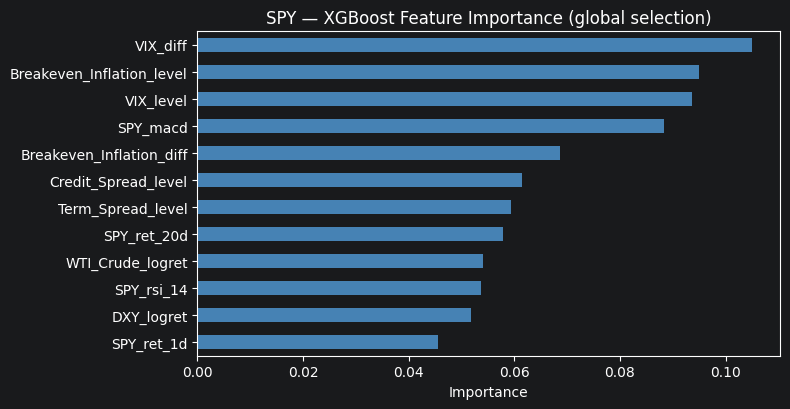

[SPY] selected features (12): ['VIX_diff', 'Breakeven_Inflation_level', 'VIX_level', 'SPY_macd', 'Breakeven_Inflation_diff', 'Credit_Spread_level', 'Term_Spread_level', 'SPY_ret_20d', 'WTI_Crude_logret', 'SPY_rsi_14', 'DXY_logret', 'SPY_ret_1d']



Best trial: 11. Best value: 8.52759e-05:  50%|█████     | 15/30 [02:27<01:33,  6.21s/it]
                                              █████▎    | 16/30 [02:27<01:47,  7.70s/it]
targets:   0%|          | 0/4 [02:44<?, ?it/s]                                          
                                              █████▎    | 16/30 [02:44<01:47,  7.70s/it]
targets:   0%|          | 0/4 [02:44<?, ?it/s]


[W 2026-04-21 12:20:45,361] Trial 16 failed with parameters: {'vsn_hidden_dim': 32, 'lstm_hidden_dim': 64, 'lstm_num_layers': 2, 'lstm_dropout': 0.19828367374345557, 'vsn_dropout': 0.004180982233688707, 'lr': 0.003695889562447545, 'batch_size': 32} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/ahnsebin/Documents/GeorgiaTech/Spring26/GTSF IC/project/.venv/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_60224/1245988912.py", line 50, in objective
    _, preds = train_one_fold(X_tr, y_tr, X_te, y_te, params=params,
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_60224/890111845.py", line 72, in train_one_fold
    optimizer.step()
  File "/Users/ahnsebin/Documents/GeorgiaTech/Spring

KeyboardInterrupt: 

In [35]:
fold_results = {}
best_params_by_target = {}
feat_cols_by_target = {}

RUN_TS = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = f"{SAVE_DIR}/{RUN_TS}"
os.makedirs(run_dir, exist_ok=True)

for target in tqdm(TARGET_TICKERS, desc="targets"):
    data = datasets[target]
    n = len(data)
    initial_train = min(int(252 * INITIAL_TRAIN_YEARS), n // 2)
    folds = expanding_window_folds(n, initial_train, TEST_SIZE, EMBARGO)
    print(f"[{target}] n={n}, folds={len(folds)}")

    # Global feature selection (once on initial train period)
    init_df  = data.iloc[:initial_train]
    X_init   = init_df.drop(columns=["target"])
    y_init   = init_df["target"]
    feat_cols, importances = select_features(X_init, y_init)
    feat_cols_by_target[target] = feat_cols

    # Feature importance chart
    importances.sort_values().plot.barh(
        figsize=(8, max(3, len(importances) * 0.35)),
        title=f"{target} — XGBoost Feature Importance (global selection)",
        color="steelblue",
    )
    plt.xlabel("Importance"); plt.tight_layout(); plt.show()
    print(f"[{target}] selected features ({len(feat_cols)}): {feat_cols}")

    # Optuna HPO
    study = tune_with_optuna(data, folds, feat_cols, n_trials=OPTUNA_TRIALS)
    best_params = study.best_params
    best_params_by_target[target] = best_params
    print(f"[{target}] best params: {best_params}")

    # Walk-forward training
    preds_df, last_model, last_mean, last_std, fold_hist = walk_forward(
        data, best_params, folds, feat_cols, desc=f"{target} folds"
    )
    mse = float(((preds_df["pred"] - preds_df["truth"]) ** 2).mean())
    hit = float(((preds_df["pred"] * preds_df["truth"]) > 0).mean())
    result = {
        "preds":       preds_df,
        "mse":         mse,
        "hit":         hit,
        "last_model":  last_model,
        "last_mean":   last_mean,
        "last_std":    last_std,
        "last_feats":  feat_cols,
        "fold_history": fold_hist,
    }
    fold_results[target] = result
    save_target(target, result, best_params, save_dir=run_dir)
    print(f"[{target}] walk-forward: n={len(preds_df)}, mse={mse:.6f}, hit={hit:.3f}\n")

summary_df = pd.DataFrame(
    {t: {"n": len(r["preds"]), "mse": r["mse"], "hit": r["hit"]}
     for t, r in fold_results.items()}
).T

with open(f"{run_dir}/best_params.json", "w") as f:
    json.dump(best_params_by_target, f, indent=2)
with open(f"{run_dir}/feat_cols.json", "w") as f:
    json.dump(feat_cols_by_target, f, indent=2)
summary_df.to_csv(f"{run_dir}/summary.csv")
print(f"Summary saved to {run_dir}/")
summary_df

In [56]:
def predict_next(model, feat_mean, feat_std, feats, recent_data,
                 lookback=LOOKBACK, device="cpu"):
    """Predict t+1 log return from the last `lookback` rows of raw (unscaled) data."""
    if len(recent_data) < lookback:
        raise ValueError(f"Need at least {lookback} rows, got {len(recent_data)}")
    window = recent_data[feats].iloc[-lookback:].values.astype(np.float32)
    scaled = ((window - feat_mean) / feat_std).astype(np.float32)
    x = torch.tensor(scaled[None, :, :]).to(device)
    model.to(device).eval()
    with torch.no_grad():
        pred, weights = model(x)
    w = weights.cpu().numpy()[0]
    return float(pred.cpu().item()), dict(zip(feats, w.mean(axis=0)))

In [59]:
# load_results() usage example (run in a new session after training):
#
run_dir = "../model/20260419_215751"   # replace with your timestamped folder
loaded  = load_results(run_dir)
pred, weights = predict_next(
    loaded["SPY"]["model"], loaded["SPY"]["feat_mean"], loaded["SPY"]["feat_std"],
    loaded["SPY"]["feats"], recent_data=datasets["SPY"].drop(columns=["target"])
)

Loaded SPY: feats=12, preds=4260, folds=71
Loaded TLT.O: feats=12, preds=4260, folds=71
Loaded GLD: feats=12, preds=4260, folds=71
Loaded XLE: feats=12, preds=4260, folds=71


# Validation

In [60]:
def validation_metrics(preds_df):
    """Compute a comprehensive set of out-of-sample regression and signal metrics.

    Metrics
    -------
    n            : Number of out-of-sample predictions.
    mse          : Mean Squared Error.
    mae          : Mean Absolute Error.
    rmse         : Root Mean Squared Error.
    ic_spearman  : Spearman rank Information Coefficient (rank correlation of
                   predictions with realised returns).
    ic_pearson   : Pearson Information Coefficient (linear correlation).
    hit_ratio    : Fraction of predictions where the predicted and realised signs
                   agree (directional accuracy).

    Parameters
    ----------
    preds_df : pd.DataFrame
        DataFrame with columns ``["pred", "truth"]``.

    Returns
    -------
    dict
        Dictionary of metric name → scalar value.
    """
    p = preds_df["pred"].values
    t = preds_df["truth"].values
    return {
        "n":            len(p),
        "mse":          float(((p - t) ** 2).mean()),
        "mae":          float(np.abs(p - t).mean()),
        "rmse":         float(np.sqrt(((p - t) ** 2).mean())),
        "ic_spearman":  float(pd.Series(p).corr(pd.Series(t), method="spearman")),
        "ic_pearson":   float(pd.Series(p).corr(pd.Series(t), method="pearson")),
        "hit_ratio":    float(((p * t) > 0).mean()),
    }


            n      mse      mae     rmse  ic_spearman  ic_pearson  hit_ratio
SPY    4260.0  0.00012  0.00727  0.01091      0.08667     0.05719    0.52770
TLT.O  4260.0  0.00009  0.00699  0.00939      0.10173     0.10472    0.51362
GLD    4260.0  0.00011  0.00731  0.01034      0.08773     0.07388    0.51526
XLE    4260.0  0.00029  0.01152  0.01694      0.08425     0.10709    0.51103


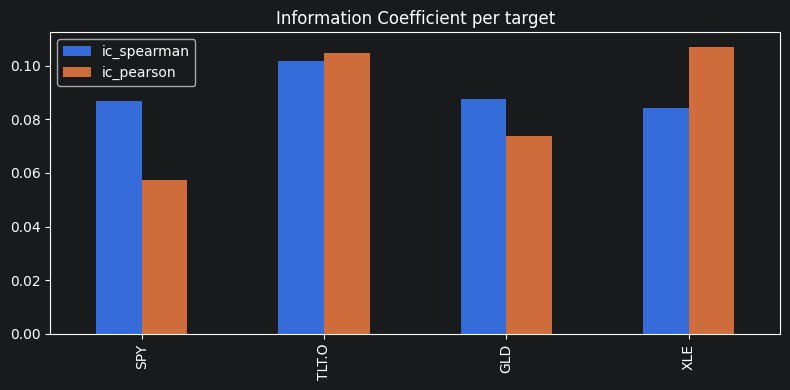

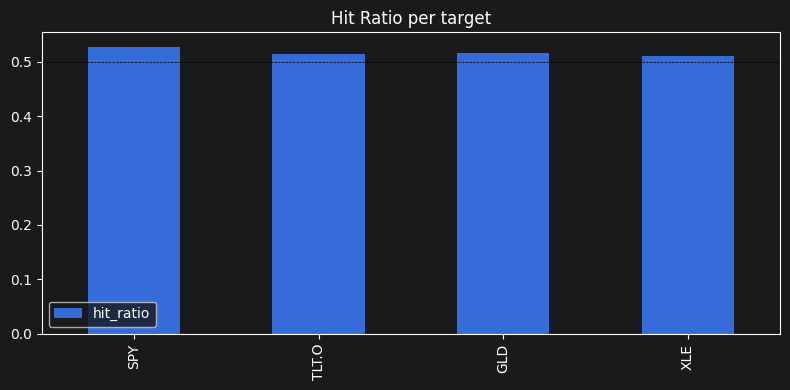

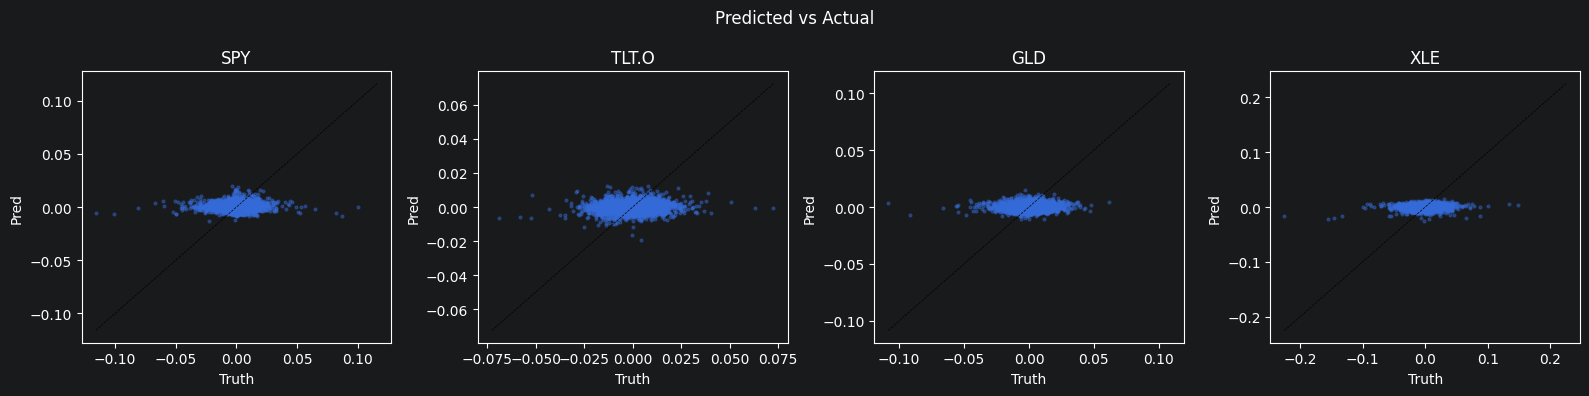

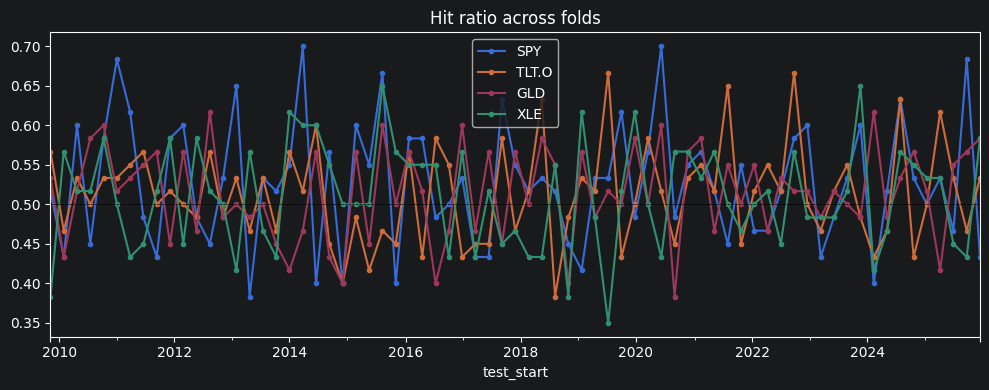

,n,mse,mae,rmse,ic_spearman,ic_pearson,hit_ratio
SPY,4260.0,0.00012,0.00727,0.01091,0.08667,0.05719,0.52770
TLT.O,4260.0,0.00009,0.00699,0.00939,0.10173,0.10472,0.51362
GLD,4260.0,0.00011,0.00731,0.01034,0.08773,0.07388,0.51526
XLE,4260.0,0.00029,0.01152,0.01694,0.08425,0.10709,0.51103


In [63]:
# Use in-memory fold_results if available (training session).
# Otherwise fall back to `loaded` which is set by load_results() in cell 46.
try:
    _val_results = fold_results
    _val_dir     = run_dir
except NameError:
    _val_results = loaded    # set by load_results() in cell 46
    _val_dir     = run_dir   # set in cell 46

validation_df = pd.DataFrame(
    {t: validation_metrics(r["preds"]) for t, r in _val_results.items()}
).T
print(validation_df.round(5))

# (1) IC — Spearman and Pearson Information Coefficient per target
validation_df[["ic_spearman", "ic_pearson"]].plot.bar(
    figsize=(8, 4), title="Information Coefficient per target")
plt.axhline(0, color="k", lw=0.5); plt.tight_layout(); plt.show()

# (2) Hit ratio — fraction of correct directional predictions
validation_df[["hit_ratio"]].plot.bar(
    figsize=(8, 4), title="Hit Ratio per target")
plt.axhline(0.5, color="k", ls="--", lw=0.5); plt.tight_layout(); plt.show()

# (3) Predicted vs Actual scatter — ideal: points on the 45-degree diagonal
fig, axes = plt.subplots(1, len(TARGET_TICKERS), figsize=(4 * len(TARGET_TICKERS), 4))
axes = axes if len(TARGET_TICKERS) > 1 else [axes]
for ax, t in zip(axes, TARGET_TICKERS):
    df = _val_results[t]["preds"]
    ax.scatter(df["truth"], df["pred"], s=4, alpha=0.4)
    lim = max(df["truth"].abs().max(), df["pred"].abs().max())
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
    ax.set_title(t); ax.set_xlabel("Truth"); ax.set_ylabel("Pred")
plt.suptitle("Predicted vs Actual"); plt.tight_layout(); plt.show()

# (4) Fold-level hit ratio stability — checks for regime-driven performance drift
fig, ax = plt.subplots(figsize=(10, 4))
for t in TARGET_TICKERS:
    fh = _val_results[t]["fold_history"].set_index("test_start")
    fh["hit"].plot(ax=ax, marker="o", ms=3, label=t)
ax.axhline(0.5, color="k", ls="--", lw=0.5)
ax.set_title("Hit ratio across folds"); plt.legend(); plt.tight_layout(); plt.show()

validation_df.round(5)


Loaded SPY: feats=12, preds=4260, folds=71
Loaded TLT.O: feats=12, preds=4260, folds=71
Loaded GLD: feats=12, preds=4260, folds=71
Loaded XLE: feats=12, preds=4260, folds=71


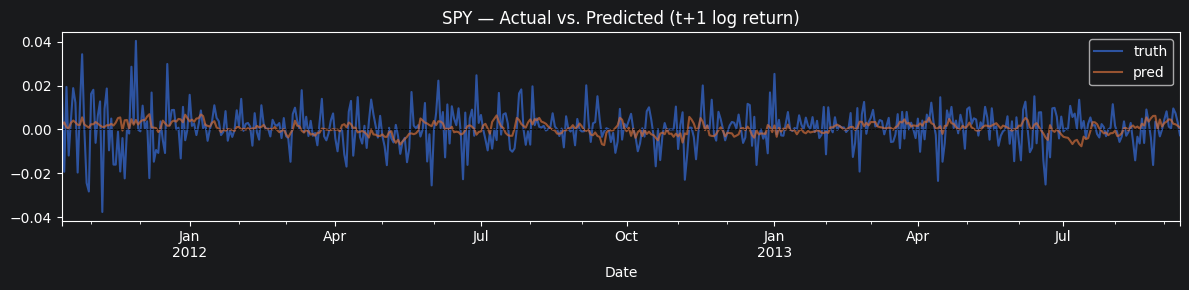

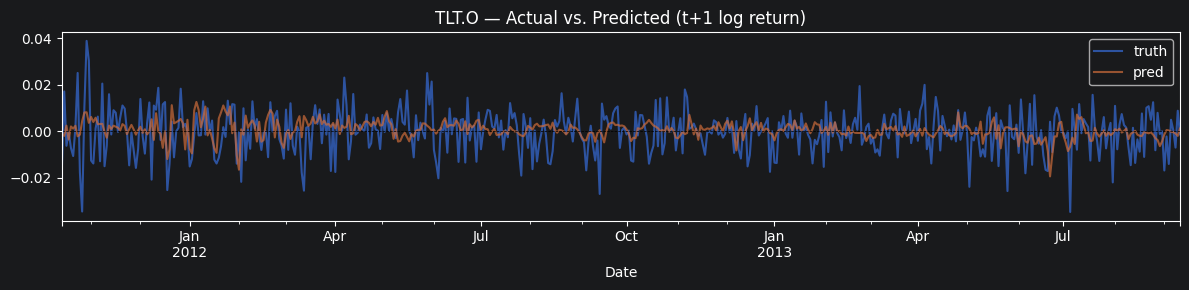

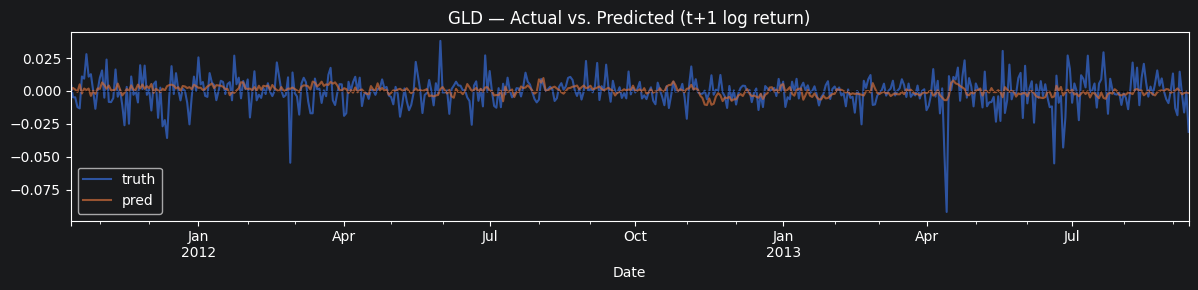

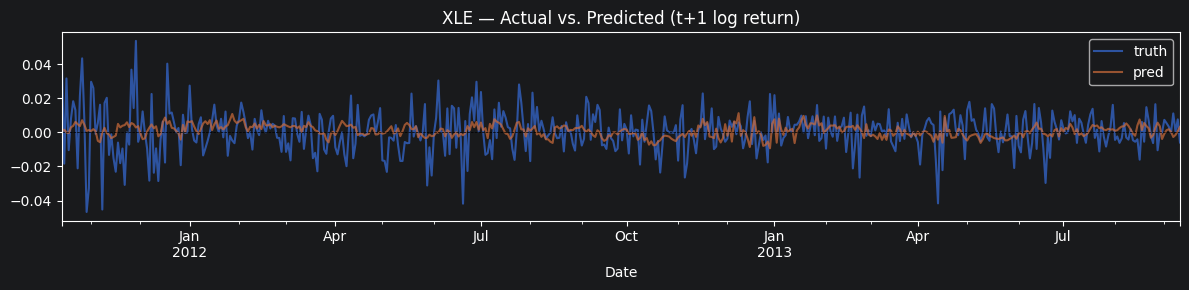

In [72]:
# Actual vs. Predicted time series per target
dr = (500,1000)

try:
    _results = fold_results
    _run_dir = run_dir
except NameError:
    _run_dir = "../model/20260419_215751"
    _results = load_results(_run_dir)

for target, r in _results.items():
    preds_df = r["preds"]
    safe = target.replace(".", "_")
    ax = preds_df[dr[0]:dr[1]].plot(y=["truth", "pred"], figsize=(12, 3), alpha=0.7,
                       title=f"{target} — Actual vs. Predicted (t+1 log return)")
    ax.set_xlabel("Date")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    plt.tight_layout()
    plt.savefig(f"{_run_dir}/{safe}_pred_vs_actual.png", dpi=100)
    plt.show()

# Backtesting

In [65]:
def backtest(preds_df, threshold=0.0):
    """Simulate a long/short strategy driven by model predictions.

    At each timestep, the strategy takes a position of +1 (long) if the model
    predicts a positive return and -1 (short) otherwise.  An optional
    ``threshold`` filters out low-conviction signals (position = 0 when
    ``|pred| <= threshold``).

    Equity curves are computed as ``exp(cumsum(log_returns))``, which is exact
    for log-return series.

    Parameters
    ----------
    preds_df : pd.DataFrame
        DataFrame with columns ``["pred", "truth"]``.
    threshold : float, optional
        Minimum absolute prediction magnitude required to take a position.
        Default is 0.0 (all signals traded).

    Returns
    -------
    pd.DataFrame
        Columns: ``position``, ``strat_ret``, ``bench_ret``, ``strat_eq``,
        ``bench_eq``.  Indexed by the same DatetimeIndex as ``preds_df``.
    """
    p = preds_df["pred"]
    t = preds_df["truth"]

    # Direction signal: +1 long, -1 short
    position = np.sign(p)
    if threshold > 0:
        # Zero out positions below the confidence threshold
        position = position.where(p.abs() > threshold, 0)

    strat_ret = position * t   # strategy daily log return
    bench_ret = t              # buy-and-hold benchmark

    return pd.DataFrame({
        "position": position,
        "strat_ret": strat_ret,
        "bench_ret": bench_ret,
        "strat_eq":  np.exp(strat_ret.cumsum()),   # strategy equity curve
        "bench_eq":  np.exp(bench_ret.cumsum()),   # benchmark equity curve
    }, index=preds_df.index)


In [66]:
def perf_metrics(ret, periods=252):
    """Compute standard annualised performance metrics from a daily log-return series.

    Metrics
    -------
    total_return  : Cumulative return over the full period (not annualised).
    cagr          : Compound Annual Growth Rate.
    ann_vol       : Annualised volatility (std × sqrt(periods)).
    sharpe        : Annualised Sharpe ratio (assumes zero risk-free rate).
    sortino       : Annualised Sortino ratio (downside volatility denominator).
    max_drawdown  : Maximum peak-to-trough drawdown of the equity curve.
    calmar        : CAGR / |max drawdown| ratio.
    win_rate      : Fraction of days with positive returns.

    Parameters
    ----------
    ret : pd.Series
        Daily log-return series.
    periods : int
        Number of trading days per year for annualisation (default 252).

    Returns
    -------
    dict
        Metric name → float value.  Returns an empty dict if ``ret`` is empty.
    """
    ret = ret.dropna()
    if len(ret) == 0:
        return {}

    equity   = np.exp(ret.cumsum())
    ann_ret  = ret.mean() * periods
    ann_vol  = ret.std()  * np.sqrt(periods)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0.0

    # Sortino: penalise only downside deviations
    downside = ret[ret < 0].std() * np.sqrt(periods)
    sortino  = ann_ret / downside if downside > 0 else 0.0

    dd        = float((equity / equity.cummax() - 1).min())
    total_ret = float(equity.iloc[-1]) - 1
    years     = len(ret) / periods
    cagr      = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0.0
    calmar    = cagr / abs(dd) if dd < 0 else 0.0

    return {
        "total_return": float(total_ret),
        "cagr":         float(cagr),
        "ann_vol":      float(ann_vol),
        "sharpe":       float(sharpe),
        "sortino":      float(sortino),
        "max_drawdown": dd,
        "calmar":       float(calmar),
        "win_rate":     float((ret > 0).mean()),
    }


        strat_total_return  strat_cagr  strat_ann_vol  strat_sharpe  \
target                                                                
SPY                19.0804      0.1942         0.1687        1.0516   
TLT.O              17.8892      0.1899         0.1472        1.1807   
GLD                14.9803      0.1781         0.1615        1.0153   
XLE               146.8470      0.3439         0.2682        1.1021   

        strat_sortino  strat_max_drawdown  strat_calmar  strat_win_rate  \
target                                                                    
SPY            1.3754             -0.3327        0.5835          0.5277   
TLT.O          1.7830             -0.2181        0.8703          0.5136   
GLD            1.3702             -0.2419        0.7364          0.5153   
XLE            1.6081             -0.3379        1.0178          0.5110   

        bench_total_return  bench_cagr  bench_ann_vol  bench_sharpe  \
target                                             

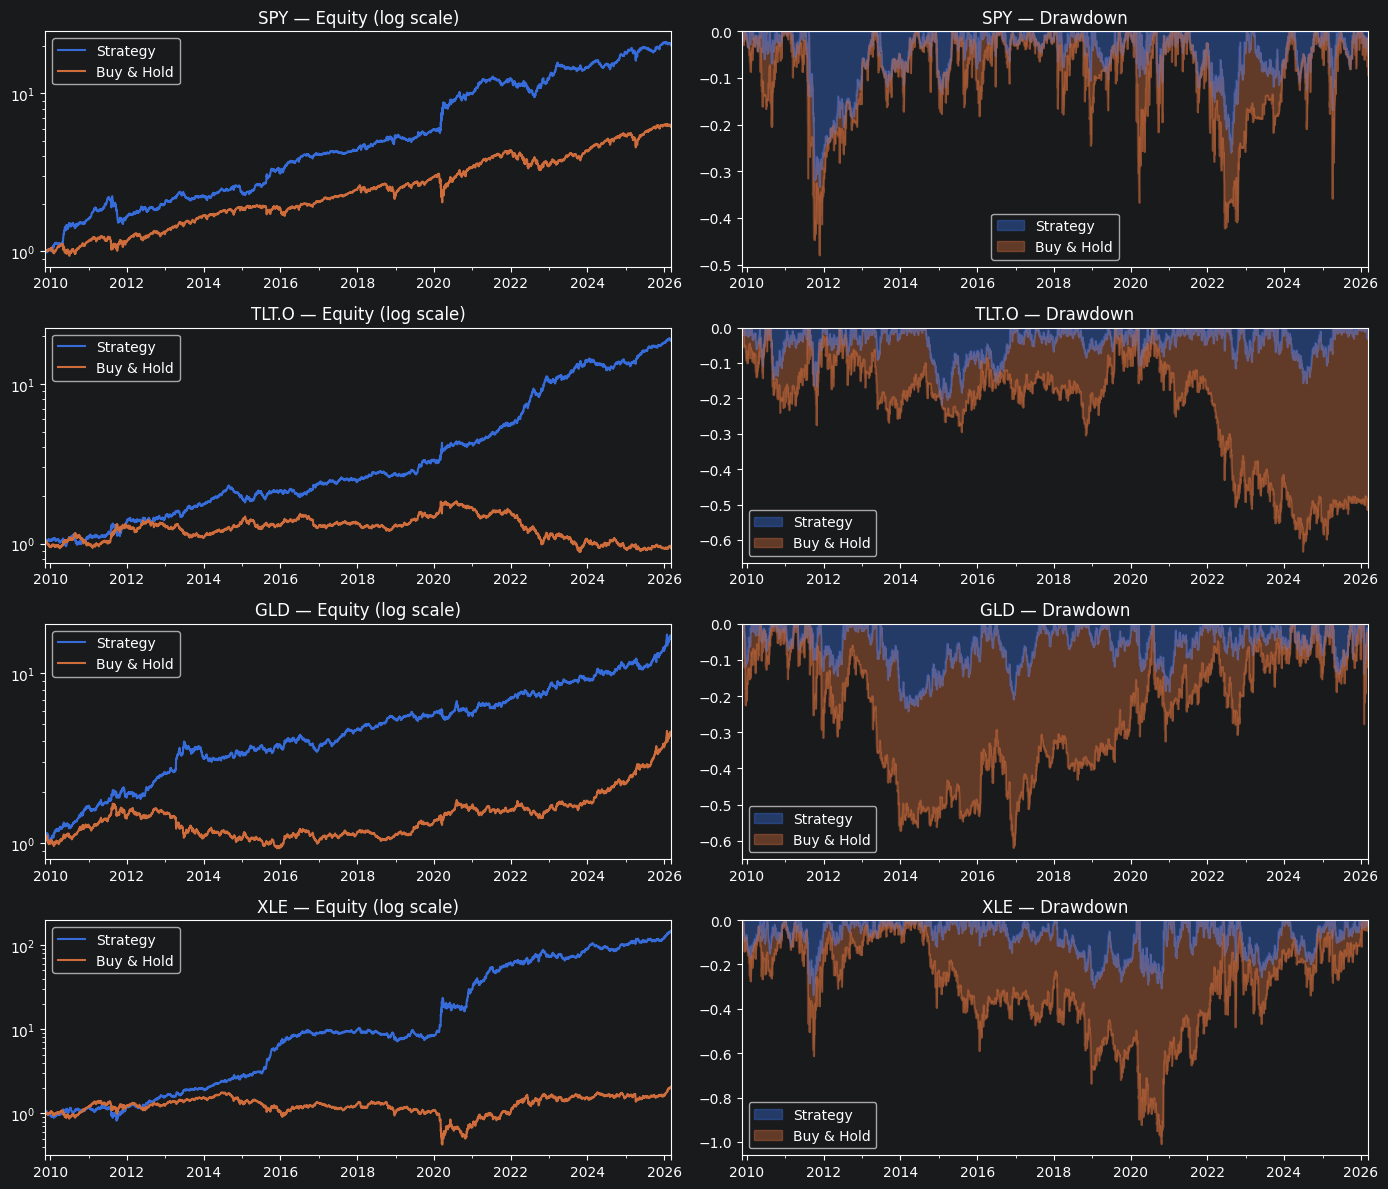

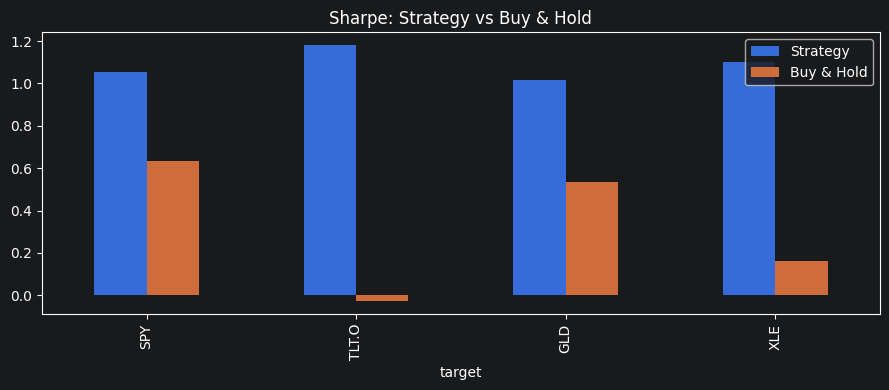

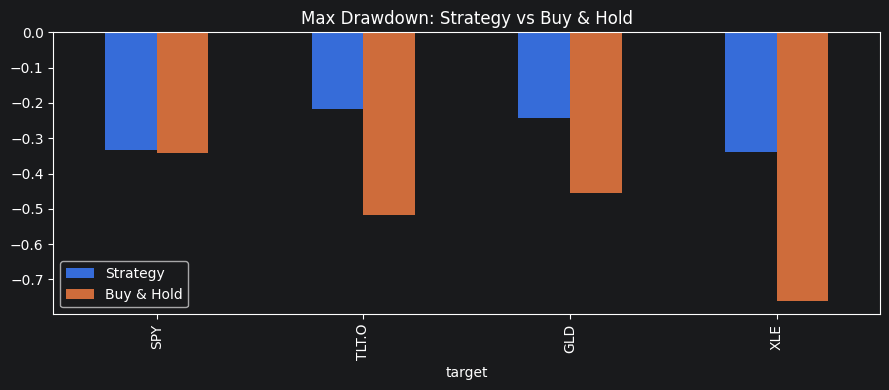

,strat_total_return,strat_cagr,strat_ann_vol,strat_sharpe,strat_sortino,strat_max_drawdown,strat_calmar,strat_win_rate,bench_total_return,bench_cagr,bench_ann_vol,bench_sharpe,bench_sortino,bench_max_drawdown,bench_calmar,bench_win_rate
target,,,,,,,,,,,,,,,,
SPY,19.0804,0.1942,0.1687,1.0516,1.3754,-0.3327,0.5835,0.5277,5.1090,0.1130,0.1690,0.6336,0.7518,-0.3410,0.3313,0.5296
TLT.O,17.8892,0.1899,0.1472,1.1807,1.7830,-0.2181,0.8703,0.5136,-0.0697,-0.0043,0.1476,-0.0290,-0.0424,-0.5176,-0.0082,0.4972
GLD,14.9803,0.1781,0.1615,1.0153,1.3702,-0.2419,0.7364,0.5153,3.3146,0.0903,0.1617,0.5348,0.6809,-0.4556,0.1983,0.5110
XLE,146.8470,0.3439,0.2682,1.1021,1.6081,-0.3379,1.0178,0.5110,1.0815,0.0443,0.2688,0.1613,0.1997,-0.7603,0.0583,0.4960


In [67]:
# Use in-memory fold_results if available (training session).
# Otherwise fall back to `loaded` which is set by load_results() in cell 46.
try:
    _bt_results = fold_results
    _bt_dir     = run_dir
except NameError:
    _bt_results = loaded    # set by load_results() in cell 46
    _bt_dir     = run_dir   # set in cell 46

backtest_results = {t: backtest(r["preds"]) for t, r in _bt_results.items()}

perf_rows = []
for t, bt in backtest_results.items():
    strat = perf_metrics(bt["strat_ret"])
    bench = perf_metrics(bt["bench_ret"])
    row   = {"target": t}
    row.update({f"strat_{k}": v for k, v in strat.items()})
    row.update({f"bench_{k}": v for k, v in bench.items()})
    perf_rows.append(row)
perf_df = pd.DataFrame(perf_rows).set_index("target")
print(perf_df.round(4))

# Equity curves + drawdowns per target
fig, axes = plt.subplots(len(TARGET_TICKERS), 2, figsize=(14, 3 * len(TARGET_TICKERS)))
axes = axes.reshape(len(TARGET_TICKERS), 2)
for i, t in enumerate(TARGET_TICKERS):
    bt = backtest_results[t]
    bt[["strat_eq", "bench_eq"]].rename(
        columns={"strat_eq": "Strategy", "bench_eq": "Buy & Hold"}
    ).plot(ax=axes[i, 0], logy=True, title=f"{t} — Equity (log scale)")
    pd.DataFrame({
        "Strategy":   bt["strat_eq"] / bt["strat_eq"].cummax() - 1,
        "Buy & Hold": bt["bench_eq"] / bt["bench_eq"].cummax() - 1,
    }).plot.area(ax=axes[i, 1], alpha=0.4, title=f"{t} — Drawdown")
plt.tight_layout(); plt.show()

# Sharpe ratio comparison: strategy vs buy-and-hold
perf_df[["strat_sharpe", "bench_sharpe"]].rename(
    columns={"strat_sharpe": "Strategy", "bench_sharpe": "Buy & Hold"}
).plot.bar(figsize=(9, 4), title="Sharpe: Strategy vs Buy & Hold")
plt.tight_layout(); plt.show()

# Maximum drawdown comparison
perf_df[["strat_max_drawdown", "bench_max_drawdown"]].rename(
    columns={"strat_max_drawdown": "Strategy", "bench_max_drawdown": "Buy & Hold"}
).plot.bar(figsize=(9, 4), title="Max Drawdown: Strategy vs Buy & Hold")
plt.tight_layout(); plt.show()

perf_df.round(4)
